# Baselines
https://colab.research.google.com/drive/1eV3j7dN5w8tg_XASIuQ5ml-vPBpXZ910?usp=sharing

My set baseline for this task are:
1. text + summary -> TF-IDF of 1&2 grams -> logistic regression -> predicted score
2. text + summary -> TF-IDF of 1&2grams -> Naive Bayes -> predicted score
I will use stratified 10-fold cross validation to get more accurate results / picture about the model in this skewed enviroment.

Downside of treating this task as classification rather than regression: sentiment score of 1 and 2 is just as different as sentiment 1 and 5... No "distance" defined on the task

In [ ]:
from data.data_loader import DataLoader
data_loader = DataLoader("data/raw/finefoods.txt")
data = data_loader.load()
data.score = data.score.astype(float)

In [ ]:
from sklearn.model_selection import train_test_split
X = data['summary'] + " " + data['text']
y = data['score'].astype(int)
# initial train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((454763,), (113691,))

## Logistic Regression

### Training

In [ ]:
import numpy as np
from tqdm import tqdm
from sklearn.pipeline import Pipeline
from utils.evaluation import evaluate_model
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer


k = 10
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
metrics = {
    "acc": [],
    "RMSE": [], # advised in task assignment
    "f1_macro": [],
    "f1_micro": []
}

all_reports = []
verbose = True

for fold, (train_index, val_index) in tqdm(enumerate(skf.split(X_train, y_train), 1)):
  X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
  y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]
  pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=10_000, ngram_range=(1, 2))),
        ('clf', LogisticRegression(max_iter=1_000, class_weight='balanced'))
  ])
  pipeline.fit(X_train_fold, y_train_fold)
  y_pred = pipeline.predict(X_val_fold)
  evaluate_model(y_val_fold, y_pred, metrics, all_reports)
  if verbose:
    for metric_name in metrics.keys():
      metric_value = metrics[metric_name][-1]
      print(f"{metric_name} for fold {fold}: {metric_value}")

for metric_name, metric_values in metrics.items():
  print(f"Mean {metric_name} over {k} folds: {np.mean(metric_values):.4f} +- {np.std(metric_values):.4f}")

1it [03:37, 217.79s/it]


Accuracy for fold 1: 0.7103
RMSE for fold 1: 0.8565
F1 macro for fold 1: 0.5955
F1 micro for fold 1: 0.7103


2it [07:28, 225.14s/it]


Accuracy for fold 2: 0.7178
RMSE for fold 2: 0.8431
F1 macro for fold 2: 0.6044
F1 micro for fold 2: 0.7178


3it [11:11, 224.27s/it]

...


Accuracy for fold 8: 0.7109
RMSE for fold 8: 0.8541
F1 macro for fold 8: 0.5984
F1 micro for fold 8: 0.7109


9it [34:07, 229.11s/it]


Accuracy for fold 9: 0.7182
RMSE for fold 9: 0.8472
F1 macro for fold 9: 0.6049
F1 micro for fold 9: 0.7182


10it [37:54, 227.41s/it]


Accuracy for fold 10: 0.7173
RMSE for fold 10: 0.8452
F1 macro for fold 10: 0.6006
F1 micro for fold 10: 0.7173
Mean acc over 10 folds: 0.7141 +- 0.0028
Mean RMSE over 10 folds: 0.8488 +- 0.0044
Mean f1_macro over 10 folds: 0.5995 +- 0.0031
Mean f1_micro over 10 folds: 0.7141 +- 0.0028


### Evaluation

In [ ]:
y_pred = pipeline.predict(X_test)
test_metrics = {
    "acc": [],
    "RMSE": [], # advised in task assignment
    "f1_macro": [],
    "f1_micro": []
}

test_report = []
evaluate_model(y_test, y_pred, metrics=test_metrics, all_reports=test_report)

In [ ]:
from utils.io_utils import (
    save_metrics,
    save_reports,
    save_pipeline
)

model_path = "models/baselines/tfidf_lr.pkl"
train_metrics_path = "metrics/train/tfidf_lr.csv"
test_metrics_path = "metrics/test/tfidf_lr.csv"
test_report_path = "reports/test/tfidf_lr.json"
train_report_path = "reports/train/tfidf_lr.json"

save_metrics(test_metrics, test_metrics_path)
save_metrics(metrics, train_metrics_path)
save_reports(all_reports, train_report_path)
save_reports(test_report, test_report_path)
save_pipeline(pipeline, model_path)

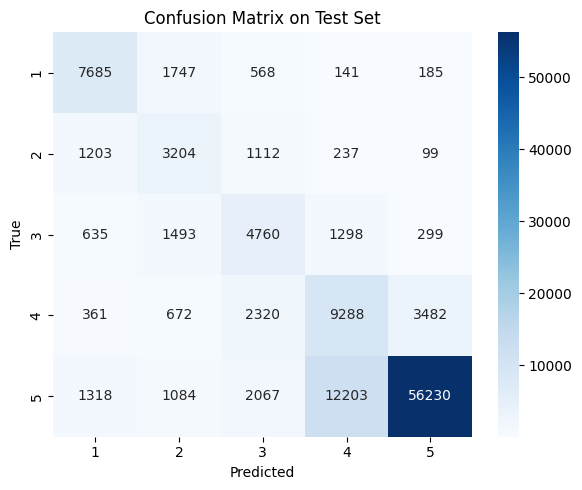

In [ ]:
from utils.evaluation import plot_confusion_matrix

plot_confusion_matrix(y_test, y_pred, title="Confusion Matrix on Test Set")

### Interpretability
Huge advantage of simple ML models such as logistic regression is theri interpretability.

In [ ]:
vectorizer = pipeline.named_steps['tfidf']
feature_names = vectorizer.get_feature_names_out()
logreg = pipeline.named_steps['clf']
coefficients = logreg.coef_

In [ ]:
for i, class_label in enumerate(logreg.classes_):
    top_indices = coefficients[i].argsort()[::-1][:10]
    print(f"\nTop words and bigrams for sentiment score {class_label}:")
    for idx in top_indices:
        print(f"{feature_names[idx]:<20} -> {coefficients[i][idx]:.4f}")


Top words and bigrams for sentiment score 1:
terrible             -> 8.9240
worst                -> 8.4711
awful                -> 8.2854
not good             -> 7.8320
horrible             -> 7.5729
disgusting           -> 7.5362
nasty                -> 7.5272
yuck                 -> 7.4729
one star             -> 6.5237
garbage              -> 6.2170

Top words and bigrams for sentiment score 2:
disappointing        -> 6.8336
not                  -> 5.3964
not good             -> 5.3100
disappointed         -> 5.2978
not very             -> 5.0273
unfortunately        -> 4.8970
mediocre             -> 4.8221
weak                 -> 4.6028
yuck                 -> 4.5716
disappointment       -> 4.5307

Top words and bigrams for sentiment score 3:
ok                   -> 6.8552
okay                 -> 6.6403
but                  -> 6.0300
average              -> 5.2527
however              -> 5.1029
not great            -> 4.8630
not bad              -> 4.4094
so so                -> 4

In [ ]:
for i, class_label in enumerate(logreg.classes_):
    top_indices = coefficients[i].argsort()[::][:10]
    print(f"\nLeast representative words and bigrams for sentiment score {class_label}:")
    for idx in top_indices:
        print(f"{feature_names[idx]:<20} -> {coefficients[i][idx]:.4f}")


Least representative words and bigrams for sentiment score 1:
great                -> -10.7506
not bad              -> -8.2172
good                 -> -8.1322
delicious            -> -7.4297
stars because        -> -7.0604
not too              -> -6.1187
excellent            -> -6.0517
stars                -> -5.7515
best                 -> -5.5881
nice                 -> -4.8805

Least representative words and bigrams for sentiment score 2:
great                -> -7.0517
good                 -> -6.5959
excellent            -> -5.8288
delicious            -> -5.4360
perfect              -> -5.2160
love it              -> -4.7323
be disappointed      -> -4.6226
not too              -> -4.5394
yummy                -> -4.4237
only problem         -> -4.3376

Least representative words and bigrams for sentiment score 3:
four stars           -> -4.2054
nasty                -> -4.1670
garbage              -> -4.1476
yuck                 -> -3.7837
not only             -> -3.6733
and vinega

In [ ]:
review_examples = X_test.sample(n=10)
review_sentiments = y_test[X_test.index]
predicted_sentiments = pipeline.predict(review_examples)
for i, (review_example, review_sentiment) in enumerate(
    zip(review_examples, review_sentiments)):
  print("REVIEW TEXT:")
  print(review_example)
  print(f"REAL SENTIMENT SCORE: {review_sentiment}")
  print(f"PREDICTED SENTIMENT SCORE: {predicted_sentiments[i]}")
  print("-------------------------------------------")

REVIEW TEXT:
I haven't received it yet. I have been waiting. This usually arrives on time and is a godsend, because when my cat runs out --oh, it's awful!! Guess I have to run to the store.
REAL SENTIMENT SCORE: 5
PREDICTED SENTIMENT SCORE: 1
-------------------------------------------
REVIEW TEXT:
What happened to dijon mustard vinaigrette? Once upon a time Delouis Fils made  a delicious and authentic dijon mustard vinaigrette.  I discovered its merits when I purchased the product at Whole Foods.  But Whole Foods stopped stocking it, so I went online to search it out.  The first time I was able to buy the same product.  This time, much to my dismay, I ordered a totally different product although the name is the same.  The new dijon mustard vinaigrette is no more French or authentic than any Kraft product.  It is glutenous and slightly sweet and--to make a long story short--I threw both bottles out.
REAL SENTIMENT SCORE: 5
PREDICTED SENTIMENT SCORE: 1
----------------------------------

In [ ]:
results_df = pd.DataFrame({
    "text": X_test,
    "true": y_test,
    "pred": y_pred
})
results_df["abs_diff"] = (results_df["true"] - results_df["pred"]).abs()
worst = results_df.sort_values("abs_diff", ascending=False).head(5)

for _, row in worst.iterrows():
    print(f"\nTRUE: {row.true}, PRED: {row.pred}, DIFF: {row.abs_diff}")
    print(row.text)
    print("-" * 50)


TRUE: 5, PRED: 1, DIFF: 4
I can't believe this has no calories I've tried other salad dressings and have been disappointed but this was delicious! Skip the ranch and dijon dressing and get this one instead.
--------------------------------------------------

TRUE: 1, PRED: 5, DIFF: 4
My 7 dogs LOVE them! After reading the negative review about the person's dog getting ill from these, I had to add my own 2 cents.  Like that person, I never buy anything made outside of the US for my dogs.  Until I bought these, on accident.  I can sympathize with his dog getting ill -- but I have 7 dogs and they all love these and have never gotten sick.  I keep the jar (love that it's a jar) by the door as a potty treat reward.  They love them.  I have all different breeds and sizes.  Even a bulldog with a sensitive tummy.  She has no problem with these.  These are the only treats I will buy from another country.  They're healthy, low calorie and my dogs will come inside from way back in the yard for t

## Naive Bayes

In [ ]:
from sklearn.naive_bayes import MultinomialNB

k = 10
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
metrics = {
    "acc": [],
    "RMSE": [],
    "f1_macro": [],
    "f1_micro": []
}

all_reports = []
verbose = True

for fold, (train_index, val_index) in tqdm(enumerate(skf.split(X_train, y_train), 1)):
  X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
  y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]
  pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=10_000, ngram_range=(1, 2))),
        ('clf', MultinomialNB())
  ])
  pipeline.fit(X_train_fold, y_train_fold)
  y_pred = pipeline.predict(X_val_fold)
  evaluate_model(y_val_fold, y_pred, metrics, all_reports)
  if verbose:
    for metric_name in metrics.keys():
      metric_value = metrics[metric_name][-1]
      print(f"{metric_name} for fold {fold}: {metric_value}")

for metric_name, metric_values in metrics.items():
  print(f"Mean {metric_name} over {k} folds: {np.mean(metric_values):.4f} +- {np.std(metric_values):.4f}")

1it [01:08, 68.78s/it]

acc for fold 1: 0.7198144116806298
RMSE for fold 1: 1.1311224326521516
f1_macro for fold 1: 0.42544479123817897
f1_micro for fold 1: 0.7198144116806298


2it [02:18, 69.61s/it]

acc for fold 2: 0.7179673241418739
RMSE for fold 2: 1.1287287671787454
f1_macro for fold 2: 0.42327688100539973
f1_micro for fold 2: 0.7179673241418739


3it [03:26, 68.55s/it]

...

acc for fold 8: 0.7176972468994635
RMSE for fold 8: 1.1259030444855567
f1_macro for fold 8: 0.4226594017730484
f1_micro for fold 8: 0.7176972468994635


9it [10:10, 67.49s/it]

acc for fold 9: 0.71818101855924
RMSE for fold 9: 1.127035253044962
f1_macro for fold 9: 0.4207512079016896
f1_micro for fold 9: 0.71818101855924


10it [11:18, 67.82s/it]

acc for fold 10: 0.7196103439176709
RMSE for fold 10: 1.1273376334772067
f1_macro for fold 10: 0.4253995885253527
f1_micro for fold 10: 0.7196103439176709
Mean acc over 10 folds: 0.7190 +- 0.0010
Mean RMSE over 10 folds: 1.1261 +- 0.0041
Mean f1_macro over 10 folds: 0.4244 +- 0.0020
Mean f1_micro over 10 folds: 0.7190 +- 0.0010


### Evaluation

In [ ]:
y_pred = pipeline.predict(X_test)
test_metrics = {
    "acc": [],
    "RMSE": [], # advised in task assignment
    "f1_macro": [],
    "f1_micro": []
}

test_report = []
evaluate_model(y_test, y_pred, metrics=test_metrics, all_reports=test_report)

In [ ]:
model_path = "models/baselines/tfidf_nb.pkl"
train_metrics_path = "metrics/train/tfidf_nb.csv"
test_metrics_path = "metrics/test/tfidf_nb.csv"
test_report_path = "reports/test/tfidf_nb.json"
train_report_path = "reports/train/tfidf_nb.json"

save_metrics(test_metrics, test_metrics_path)
save_metrics(metrics, train_metrics_path)
save_reports(all_reports, train_report_path)
save_reports(test_report, test_report_path)
save_pipeline(pipeline, model_path)

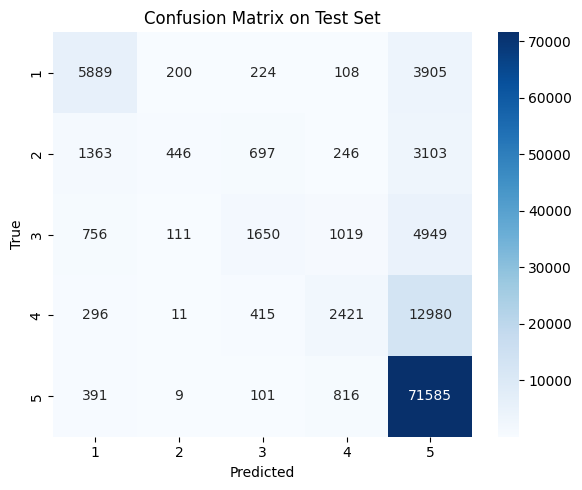

In [ ]:
plot_confusion_matrix(y_test, y_pred, title="Confusion Matrix on Test Set")

### Interpretability
Huge advantage of simple ML models such as logistic regression is theri interpretability.

In [ ]:
review_examples = X_test.sample(n=10)
review_sentiments = y_test[X_test.index]
predicted_sentiments = pipeline.predict(review_examples)
for i, (review_example, review_sentiment) in enumerate(
    zip(review_examples, review_sentiments)):
  print("REVIEW TEXT:")
  print(review_example)
  print(f"REAL SENTIMENT SCORE: {review_sentiment}")
  print(f"PREDICTED SENTIMENT SCORE: {predicted_sentiments[i]}")
  print("-------------------------------------------")

REVIEW TEXT:
Definitely NOT Espresso! This is absolutely the worst coffee I've ever had! I was expecting a dark, full flavored, bold coffee - AN ESPRESSO! Instead what I got was the equivalent of a supermarket, off the shelf, canned coffee. You know the type, weak, no flavor, stale, so thin you can see through it. If you like supermarket, canned coffee then this is for you. If  you're looking for an Espresso, Stay Away! This isn't it.
REAL SENTIMENT SCORE: 5
PREDICTED SENTIMENT SCORE: 1
-------------------------------------------
REVIEW TEXT:
Great Product This product works great for an alertness boost.  There is no sugar rush.  Just a little caffeine and B vitamins.  No crash either. I would recommend this product to everyone.
REAL SENTIMENT SCORE: 5
PREDICTED SENTIMENT SCORE: 5
-------------------------------------------
REVIEW TEXT:
rewarding self I have used this product for at least 3 yrs.  When both stores in my town that carry it were out for over a month I went looking and fou

In [ ]:
results_df = pd.DataFrame({
    "text": X_test,
    "true": y_test,
    "pred": y_pred
})
results_df["abs_diff"] = (results_df["true"] - results_df["pred"]).abs()
worst = results_df.sort_values("abs_diff", ascending=False).head(5)

for _, row in worst.iterrows():
    print(f"\nTRUE: {row.true}, PRED: {row.pred}, DIFF: {row.abs_diff}")
    print(row.text)
    print("-" * 50)


TRUE: 1, PRED: 5, DIFF: 4
HORRIBLY SUGARY SWEET!!! Just got a 6 pack of Better'n Peanut Butter 16 Oz original. My elderly mother pointed out it was full of sugars and syrups- i had not tried it yet. I found it is horribly sweet and sugary, tastes like a honey/syrup-peanut butter and nothing like peanut butter at all. regret that i now have 6 jars, would never buy it again
--------------------------------------------------

TRUE: 1, PRED: 5, DIFF: 4
Why do their organic foods contain gelatin??? I used to buy Gerber baby foods and was thrilled when they started carrying organic foods. Then I discovered that they add gelatin! Why? It is disgusting and has absolutely no nutritional value.  I will not be buying Gerber products again. Earth's Best is actually organic.
--------------------------------------------------

TRUE: 1, PRED: 5, DIFF: 4
Better than peanut butter?  lol Whoever titled this product has a lot of nerve.  It tastes like tapioca, which is exactly what's in it.
------------